In [42]:

from ALY6140.Capstone_final_group1.amazon_analysis import eda, data_preprocessing as dp, random_forest_model as rfm, \
    naive_bayes_model as nbm, sentiment_analysis as sa, logistic_regression_model as lrm

In [43]:
# Load and clean data
df_raw = dp.load_amazon_data("Amazon_Products.csv")
df_clean = dp.clean_mod_df(df_raw)
df_logistic = dp.clean_df_for_logistic(df_raw)
print("Shape after cleaning:", df_logistic.shape)
print(df_logistic.head())


Shape after cleaning: (8565, 9)
   price number_available_in_stock number_of_reviews  \
0   3.42                     5 new                15   
1  16.99                       NaN                 2   
2   9.99                     2 new                17   
3  39.99                       NaN                 1   
4  32.19                       NaN                 3   

  number_of_answered_questions average_review_rating  \
0                            1    4.9 out of 5 stars   
1                            1    4.5 out of 5 stars   
2                            2    3.9 out of 5 stars   
3                            2    5.0 out of 5 stars   
4                            2    4.7 out of 5 stars   

                                 product_information  \
0  Technical Details Item Weight640 g Product Dim...   
1  Technical Details Manufacturer recommended age...   
2  Technical Details Manufacturer recommended age...   
3  Technical Details Item Weight259 g Product Dim...   
4  Technical D

C:\Users\JunhuiHuTEST\PycharmProjects\ALY6140\testfile\amazon_analysis\data_preprocessing.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["item_type"] = df['number_available_in_stock'].str.extract(r"(new|used)", flags=re.IGNORECASE)
C:\Users\JunhuiHuTEST\PycharmProjects\ALY6140\testfile\amazon_analysis\data_preprocessing.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["price_new"] = (df["price"]
C:\Users\JunhuiHuTEST\PycharmProjects\ALY6140\testfile\amazon_analysis\data_preprocessing.py:52: 

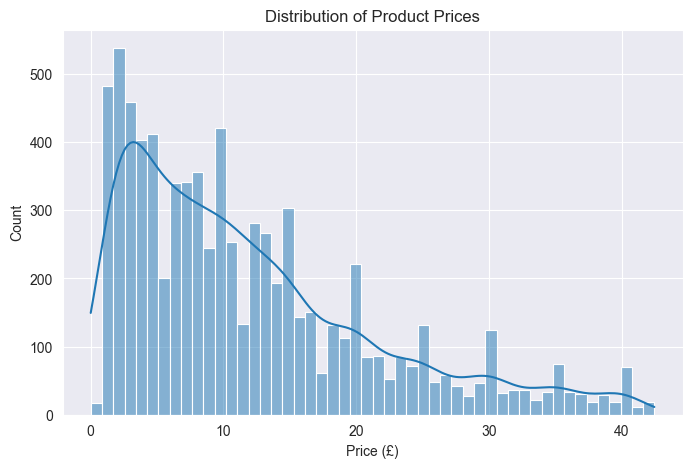

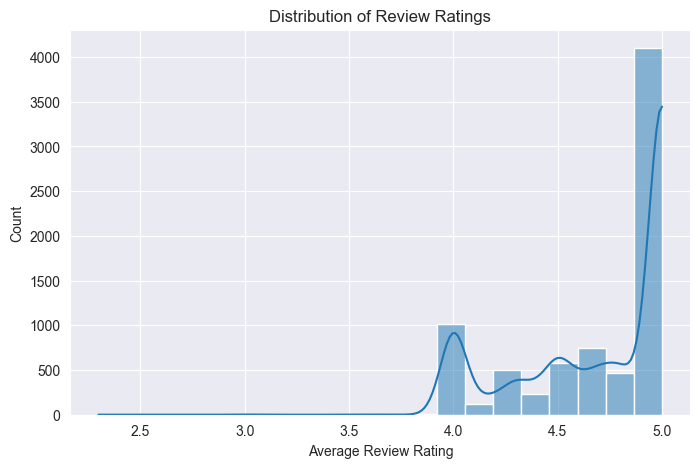

C:\Users\JunhuiHuTEST\PycharmProjects\ALY6140\testfile\amazon_analysis\eda.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


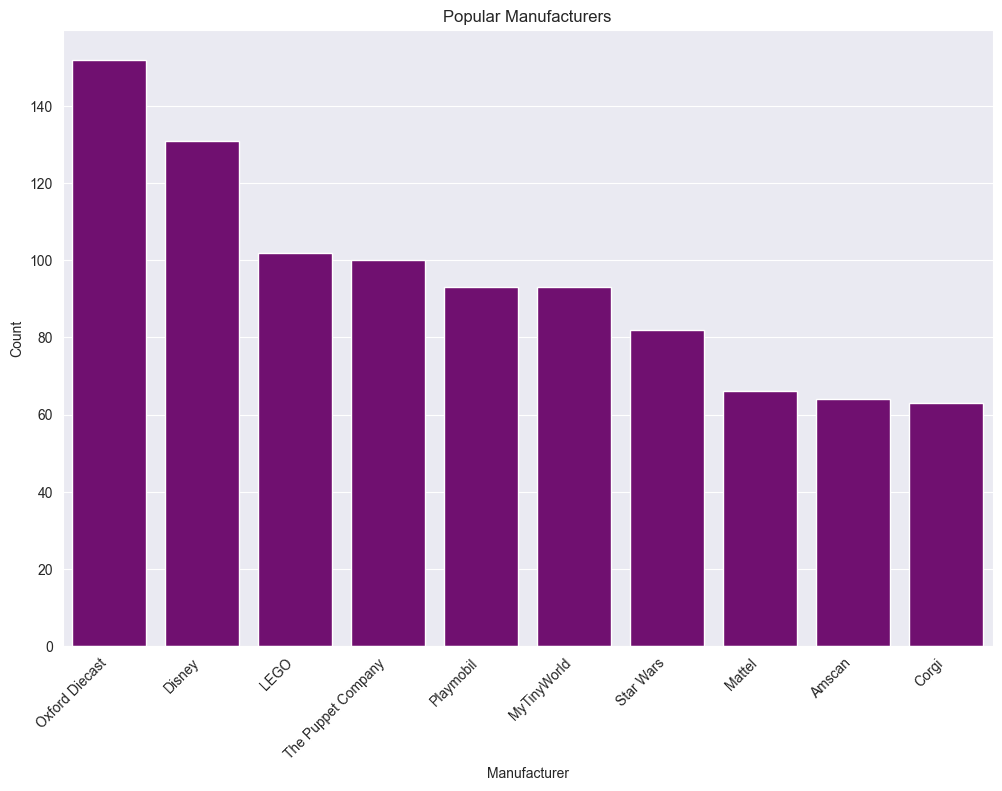

C:\Users\JunhuiHuTEST\PycharmProjects\ALY6140\testfile\amazon_analysis\eda.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


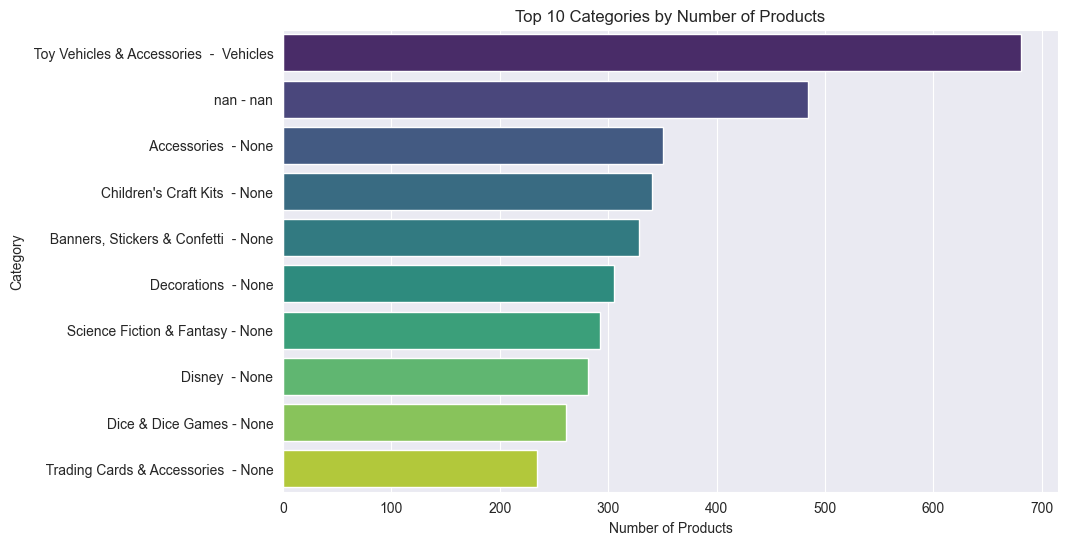

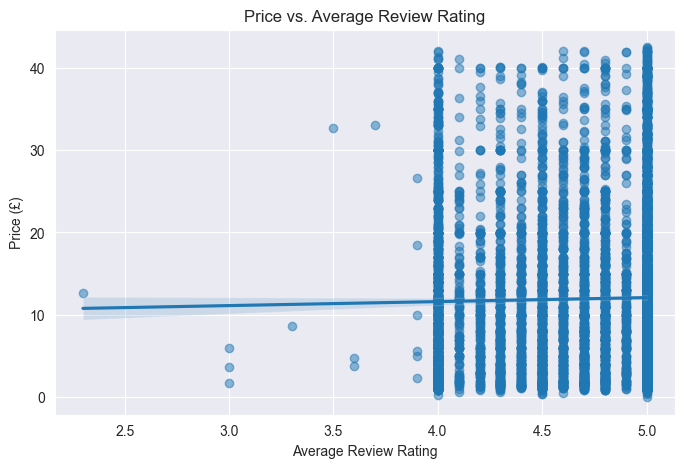

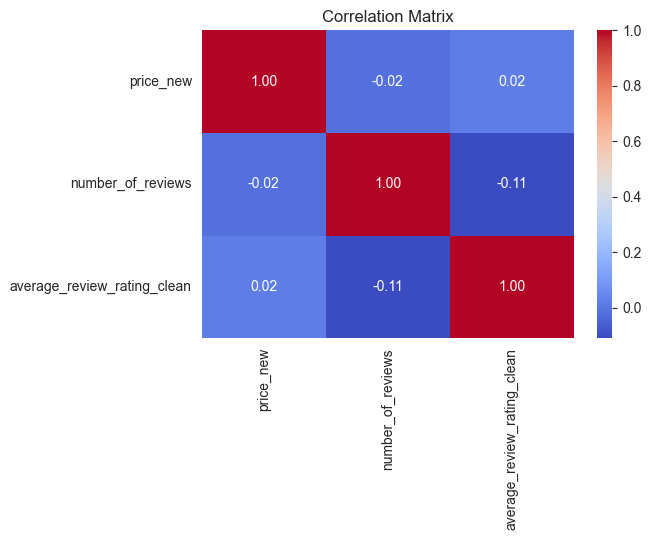

In [44]:
# Exploratory Data Analysis
eda.plot_price_distribution(df_clean)
eda.plot_review_distribution(df_clean)
eda.plot_manufacturer_counts(df_clean)
eda.plot_category_counts(df_clean)
eda.plot_price_vs_rating(df_clean)
eda.plot_correlation_matrix(df_clean)

Logistic Regression Accuracy: 0.63
Confusion Matrix:
[[573 284]
 [350 506]]
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.67      0.64       857
           1       0.64      0.59      0.61       856

    accuracy                           0.63      1713
   macro avg       0.63      0.63      0.63      1713
weighted avg       0.63      0.63      0.63      1713



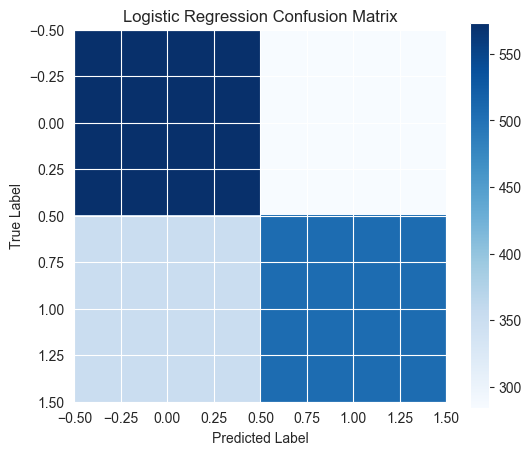

LogisticRegression()

In [45]:
# For logistic regression, use the original data cleaned appropriately:
# df_logistic = dp.clean_df_for_logistic(df_raw)
lrm.train_logistic_regression(df_raw)

Naïve Bayes Model Accuracy: 0.6252497003595685
Classification Report:
               precision    recall  f1-score   support

        High       0.64      0.76      0.69       820
         Low       0.78      0.54      0.64       878
      Medium       0.51      0.58      0.54       805

    accuracy                           0.63      2503
   macro avg       0.64      0.63      0.62      2503
weighted avg       0.65      0.63      0.63      2503



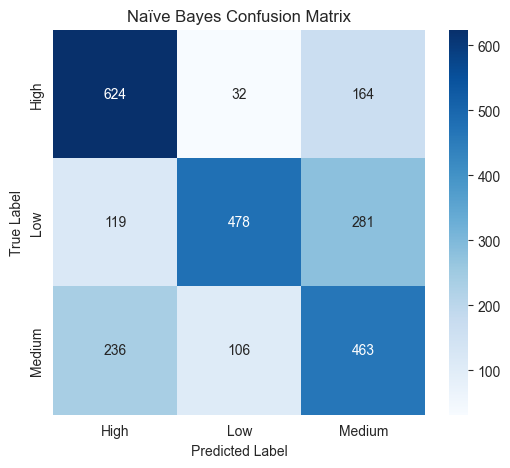

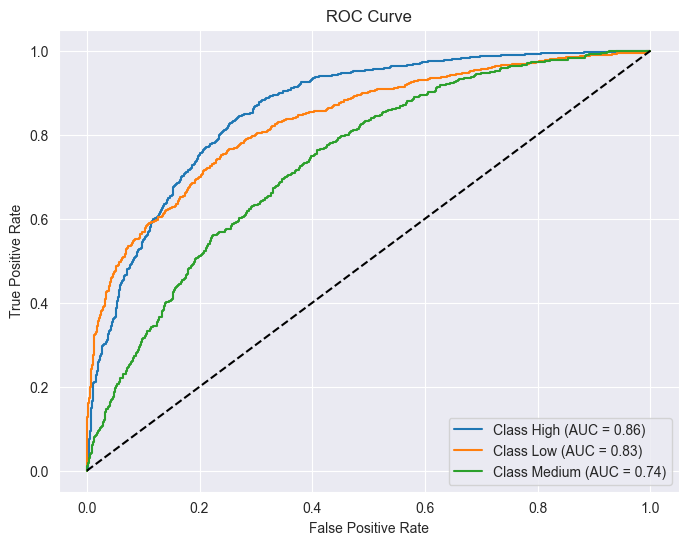

MultinomialNB()

In [46]:
# Train Naïve Bayes classification model
nbm.train_naive_bayes(df_clean)

Random Forest Cross-Validation Accuracy Scores: [0.829005193767479, 0.8421893727526968, 0.8393927287255294, 0.8381294964028777, 0.837330135891287]
Mean Accuracy: 0.837209385507974
Standard Deviation: 0.004421248859588047


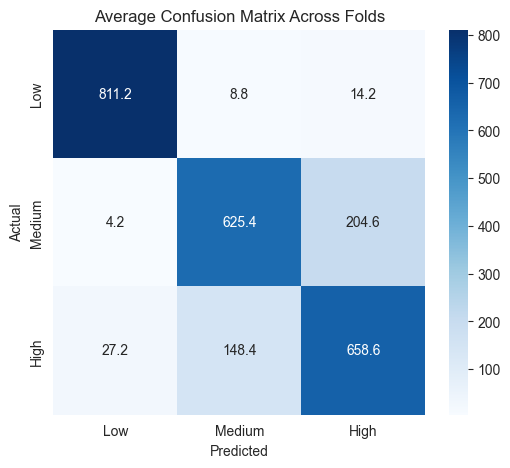

RandomForestClassifier(random_state=42)

In [47]:
# Train Random Forest classification model
rfm.train_random_forest(df_clean)

In [48]:
# Perform sentiment analysis (assuming df_raw has necessary text columns)
sa.perform_sentiment_analysis(df_raw)

Column 'rating' not found. Setting default value 0.
Column 'review_length' not found. Setting default value 0.
SVM Model Accuracy: 0.5495118549511855
              precision    recall  f1-score   support

           0       0.57      0.35      0.43      1758
           1       0.54      0.74      0.63      1827

    accuracy                           0.55      3585
   macro avg       0.55      0.55      0.53      3585
weighted avg       0.55      0.55      0.53      3585



C:\Users\JunhuiHuTEST\PycharmProjects\ALY6140\.venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:21:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Model Accuracy: 0.9615062761506277
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      1758
           1       0.95      0.97      0.96      1827

    accuracy                           0.96      3585
   macro avg       0.96      0.96      0.96      3585
weighted avg       0.96      0.96      0.96      3585

Linear Regression - Mean Absolute Error: 0.44549623174603076
Linear Regression - Mean Squared Error: 0.25466638572773526
Linear Regression - R2 Score: -0.00040287988440823597


(SVC(class_weight='balanced'),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=None,
               n_jobs=None, num_parallel_tree=None, random_state=None, ...),
 LinearRegression())